# Loss functions

> A set of custom loss functions

In [ ]:
#| default_exp losses

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *
from torch import randn, randint

In [ ]:
#| export

# =================================
# Scientific
# =================================
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# =================================
# PyTorch
# =================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import sigmoid
from torch.nn import CrossEntropyLoss
from torch.nn.modules.loss import _Loss

# =================================
# MONAI
# =================================
import monai.losses as ml
from monai.utils import LossReduction, ensure_tuple_rep

# =================================
# fastai
# =================================
from fastai.vision.all import (
    Any,
    CrossEntropyLossFlat,
    mae,
    mse,
)

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *

## Loss wrappers

In [ ]:
#| export
MultiScaleLoss = ml.MultiScaleLoss
MaskedLoss = ml.MaskedLoss
DeepSupervisionLoss = ml.DeepSupervisionLoss

## Reconstruction losses


In [ ]:
#| export

class MSELoss(nn.MSELoss):
    """
    Mean Squared Error (MSE) loss.

    Computes the average squared difference between the predicted values
    and the target values. MSE penalizes larger errors more strongly than
    smaller errors because the residual is squared.

    The element-wise MSE is defined as:

        L_i = (input_i - target_i)^2

    For ``reduction="mean"``, the loss is:

        L = 1/N * sum_i (input_i - target_i)^2

    For ``reduction="sum"``, the loss is:

        L = sum_i (input_i - target_i)^2

    For ``reduction="none"``, the unreduced element-wise squared errors
    are returned.

    MSE is commonly used for regression and image restoration tasks,
    where it measures the squared Euclidean distance between predicted
    and target values.

    Parameters
    ----------
    reduction : str, optional
        Specifies the reduction applied to the output:

        - ``"mean"``: average all element-wise squared errors.
        - ``"sum"``: sum all element-wise squared errors.
        - ``"none"``: return the element-wise squared errors.

        Default is ``"mean"``.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`torch.nn.MSELoss` and therefore retains the same behavior
    and API as the underlying PyTorch implementation.

    Examples
    --------
    >>> loss = MSELoss()
    >>> input = torch.tensor([1.0, 2.0, 4.0])
    >>> target = torch.tensor([1.0, 3.0, 2.0])
    >>> loss(input, target)
    tensor(1.6667)
    """

    pass


In [ ]:
#| export

class MAELoss(nn.L1Loss):
    """
    Mean Absolute Error (MAE) loss.

    Computes the average absolute difference between the predicted values
    and the target values. Unlike Mean Squared Error (MSE), MAE penalizes
    errors linearly, making it less sensitive to large outliers.

    The element-wise MAE is defined as:

        L_i = |input_i - target_i|

    For ``reduction="mean"``, the loss is:

        L = 1/N * sum_i |input_i - target_i|

    For ``reduction="sum"``, the loss is:

        L = sum_i |input_i - target_i|

    For ``reduction="none"``, the unreduced element-wise absolute errors
    are returned.

    MAE is commonly used for regression, image restoration, and
    reconstruction tasks where robustness to large errors is desirable.

    Parameters
    ----------
    reduction : str, optional
        Specifies the reduction applied to the output:

        - ``"mean"``: average all element-wise absolute errors.
        - ``"sum"``: sum all element-wise absolute errors.
        - ``"none"``: return the element-wise absolute errors.

        Default is ``"mean"``.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`torch.nn.L1Loss` and therefore retains the same behavior
    and API as the underlying PyTorch implementation.

    Examples
    --------
    >>> loss = MAELoss()
    >>> input = torch.tensor([1.0, 2.0, 4.0])
    >>> target = torch.tensor([1.0, 3.0, 2.0])
    >>> loss(input, target)
    tensor(1.0000)
    """

    pass

In [ ]:
#| export

class SSIMLoss(ml.SSIMLoss):
    """
    Structural Similarity Index Measure (SSIM) loss.

    SSIM is a perceptual image-similarity measure that compares local
    luminance, contrast, and structural information between an input
    image and a target image. It is particularly useful for image
    reconstruction and restoration tasks where perceptual structure is
    more important than purely pixel-wise differences.

    The SSIM index between two local image regions is defined as:

        SSIM(x, y) =
            ((2 * μ_x * μ_y + C1)
             * (2 * σ_xy + C2))
            /
            ((μ_x² + μ_y² + C1)
             * (σ_x² + σ_y² + C2))

    where:

        μ_x, μ_y
            Local means of the input and target.

        σ_x², σ_y²
            Local variances of the input and target.

        σ_xy
            Local covariance between the input and target.

        C1, C2
            Stabilizing constants that prevent numerical instability.

    The SSIM loss is defined as:

        L_SSIM = 1 - SSIM(x, y)

    The implementation uses MONAI's SSIM formulation, including its
    configurable spatial dimensions, Gaussian filtering, kernel size,
    and reduction behavior.

    Parameters
    ----------
    spatial_dims : int
        Number of spatial dimensions of the input images. Typically
        ``2`` for 2D images or ``3`` for volumetric images.
    data_range : float
        Dynamic range of the input data.
    kernel_sigma : float or sequence of float
        Standard deviation of the Gaussian kernel used to compute
        local statistics.
    kernel_size : int or sequence of int
        Size of the Gaussian kernel.
    win_size : int or sequence of int, optional
        Alternative window-size parameter supported by MONAI's
        implementation.
    k1 : float
        Constant used to calculate ``C1``.
    k2 : float
        Constant used to calculate ``C2``.
    reduction : str
        Specifies the reduction applied to the output:

        - ``"mean"``: average the loss.
        - ``"sum"``: sum the loss.
        - ``"none"``: return the unreduced loss.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`monai.losses.SSIMLoss`. The underlying MONAI implementation
    is retained, so its full API and behavior are preserved.

    SSIM is complementary to pixel-wise losses such as :class:`MSELoss`
    and :class:`MAELoss`: two images can have relatively similar pixel
    values while differing structurally, or have small structural
    differences despite relatively large pixel-wise errors.

    Examples
    --------
    >>> loss = SSIMLoss(spatial_dims=2)
    >>> input = torch.rand(1, 1, 64, 64)
    >>> target = torch.rand(1, 1, 64, 64)
    >>> value = loss(input, target)
    """

    pass

In [ ]:
#| export

class PatchAdversarialLoss(ml.PatchAdversarialLoss):
    """
    Patch-based adversarial loss for generative adversarial networks (GANs).

    Computes an adversarial loss from the patch-level predictions produced
    by a discriminator. Unlike a conventional discriminator that produces
    a single scalar prediction for an entire image, a patch discriminator
    produces a spatial map of predictions, where each value corresponds to
    the realism of a local image patch.

    This type of loss is commonly used in image-to-image translation,
    image synthesis, and image restoration, where encouraging realistic
    local structures can improve the visual quality of generated images.

    For a discriminator prediction ``D(x)``, the adversarial objective
    depends on whether the prediction corresponds to a real or generated
    image. A generic binary adversarial formulation can be written as:

        L_D = L_adv(D(x_real), real)
            + L_adv(D(x_fake), fake)

    where ``L_adv`` is the selected adversarial loss function.

    For a generator, the adversarial objective encourages the discriminator
    to classify generated patches as real:

        L_G = L_adv(D(x_fake), real)

    The exact mathematical formulation depends on the adversarial loss
    mode selected by MONAI, such as least-squares or hinge-style losses.

    Parameters
    ----------
    criterion : str
        Adversarial loss criterion used to evaluate discriminator
        predictions. The available criteria depend on the underlying
        MONAI implementation.
    reduction : str
        Specifies how the patch-wise losses are reduced. Supported
        values depend on the underlying MONAI implementation.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`monai.losses.PatchAdversarialLoss`. The underlying MONAI
    implementation is retained, including its handling of patch-based
    discriminator outputs and supported adversarial criteria.

    Because the discriminator produces multiple patch predictions,
    the loss is generally computed over the discriminator output map
    rather than a single scalar prediction.

    Examples
    --------
    >>> loss = PatchAdversarialLoss(criterion="least_squares")
    >>> discriminator_output = torch.randn(2, 1, 16, 16)
    >>> value = loss(discriminator_output, target_is_real=True)

    References
    ----------
    Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley,
    D., Ozair, S., Courville, A., & Bengio, Y. (2014).
    Generative Adversarial Nets. Advances in Neural Information
    Processing Systems, 27.

    Isola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017).
    Image-to-Image Translation with Conditional Adversarial Networks.
    Proceedings of the IEEE Conference on Computer Vision and Pattern
    Recognition, 1125-1134.
    """

    pass

In [ ]:
#| export

class PerceptualLoss(ml.PerceptualLoss):
    """
    Perceptual loss based on deep feature representations.

    Compares an input image and a target image using feature
    representations extracted from a pretrained neural network rather
    than comparing the images only at the pixel level.

    The underlying network extracts features at one or more layers.
    The perceptual loss measures the discrepancy between the
    corresponding feature representations:

        L_perceptual =
            sum_l w_l * D(phi_l(input), phi_l(target))

    where:

        phi_l
            Feature representation extracted from layer ``l`` of the
            pretrained network.

        w_l
            Weight assigned to feature layer ``l``.

        D
            Distance function used to compare the feature maps.

    By comparing high-level feature representations, perceptual loss can
    encourage generated or reconstructed images to preserve semantic
    structures and visual characteristics that may not be well captured
    by pixel-wise losses such as MSE or MAE.

    It is commonly used for image synthesis, super-resolution,
    reconstruction, image restoration, and generative models.

    Parameters
    ----------
    network : torch.nn.Module
        Neural network used to extract perceptual features. Typically a
        pretrained classification or feature-extraction network.
    network_type : str
        Type of network architecture used for feature extraction.
    feature_layers : sequence of int
        Layers from which feature representations are extracted.
    is_fake_3d : bool
        Whether the inputs should be treated as fake 3D data when using
        a 2D feature-extraction network.
    pretrained : bool
        Whether to use pretrained network weights.
    spatial_dims : int
        Number of spatial dimensions of the input data.
    reduction : str
        Reduction applied to the feature-space losses.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`monai.losses.PerceptualLoss`. The underlying MONAI
    implementation is retained, including its feature-extraction
    network, layer selection, and dimensionality handling.

    Perceptual loss is generally complementary to pixel-wise losses.
    Pixel losses directly penalize intensity differences, whereas
    perceptual loss penalizes differences in learned feature space.
    Combining them can therefore provide both pixel-level fidelity and
    preservation of higher-level image structure.

    Examples
    --------
    >>> loss = PerceptualLoss(
    ...     spatial_dims=2,
    ...     network_type="alex",
    ... )
    >>> input = torch.rand(1, 3, 128, 128)
    >>> target = torch.rand(1, 3, 128, 128)
    >>> value = loss(input, target)

    References
    ----------
    Johnson, J., Alahi, A., & Fei-Fei, L. (2016).
    Perceptual Losses for Real-Time Style Transfer and Super-Resolution.
    European Conference on Computer Vision, 694-711.

    Zhang, R., Isola, P., Efros, A. A., Shechtman, E., & Wang, O. (2018).
    The Unreasonable Effectiveness of Deep Features as a Perceptual
    Metric. Proceedings of the IEEE Conference on Computer Vision and
    Pattern Recognition, 586-595.
    """

    pass

In [ ]:
#| export

class JukeboxLoss(ml.JukeboxLoss):
    """
    Jukebox loss for vector-quantized hierarchical autoencoders.

    This loss is used in Jukebox-style architectures with multiple
    vector-quantization levels. It measures the discrepancy between the
    encoder outputs and their corresponding quantized representations,
    encouraging the encoder to produce representations that are well
    represented by the learned codebook.

    For a quantization level ``l``, the commitment/codebook loss can be
    expressed conceptually as:

        L_l = ||sg[z_e] - z_q||²
              + β ||z_e - sg[z_q]||²

    where:

    - ``z_e`` is the encoder representation,
    - ``z_q`` is the corresponding quantized/codebook representation,
    - ``sg[·]`` denotes stop-gradient,
    - ``β`` controls the encoder commitment term.

    For multiple quantization levels, the total loss is typically a
    weighted combination of the losses associated with the different
    levels:

        L = Σ_l w_l L_l

    The exact computation depends on the inputs and configuration of the
    underlying MONAI implementation.

    Jukebox-style losses are particularly useful for models that learn
    discrete latent representations through vector quantization, such
    as hierarchical VQ-VAE architectures.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.JukeboxLoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.JukeboxLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.JukeboxLoss`. The constructor and forward
    behavior are inherited unchanged from MONAI, ensuring compatibility
    with the installed MONAI version.

    Examples
    --------
    >>> loss = JukeboxLoss(...)
    >>> value = loss(input, target)

    References
    ----------
    Dhariwal, P., et al. (2020).
    Jukebox: A Generative Model for Music.
    arXiv:2005.00341.
    """
    pass

### Fourier Ring Correlation

In [ ]:
#| export
def radial_mask(r, cx, cy, sx, sy, delta=1):
    """
    Create a radial ring mask.
    """

    x = np.arange(sx)
    y = np.arange(sy)

    xx, yy = np.meshgrid(x, y, indexing="xy")

    dist2 = (xx - cx) ** 2 + (yy - cy) ** 2

    inner = dist2 > (r[0] ** 2)
    outer = dist2 <= ((r[0] + delta) ** 2)

    return inner & outer

In [ ]:
#| export
def get_fourier_ring_correlations(image1, image2):
    """
    Compute Fourier Ring Correlation curve.
    """

    device = image1.device

    H, W = image1.shape[-2:]

    freq_nyq = min(H, W) // 2

    radii = torch.arange(freq_nyq, device=device).float()

    spatial_freq = radii / freq_nyq

    radial_masks = torch.stack([
        torch.tensor(
            radial_mask(
                r=[int(r)],
                cx=W // 2,
                cy=H // 2,
                sx=W,
                sy=H,
                delta=1,
            ),
            device=device,
            dtype=torch.bool,
        )
        for r in radii
    ])

    fft1 = torch.fft.fftshift(torch.fft.fft2(image1))
    fft2 = torch.fft.fftshift(torch.fft.fft2(image2))

    fft1 = fft1.unsqueeze(0).expand(freq_nyq, -1, -1)
    fft2 = fft2.unsqueeze(0).expand(freq_nyq, -1, -1)

    t1 = fft1 * radial_masks
    t2 = fft2 * radial_masks

    numerator = torch.abs(
        torch.real((t1 * t2.conj()).sum(dim=(-2, -1)))
    )

    denom = torch.sqrt(
        (t1.abs() ** 2).sum(dim=(-2, -1)) *
        (t2.abs() ** 2).sum(dim=(-2, -1)) +
        1e-8
    )

    frc = numerator / denom

    frc = torch.nan_to_num(frc, nan=0.0, posinf=0.0, neginf=0.0)

    return frc, spatial_freq

In [ ]:
#| export
def FCRCutoff(
    image1,
    image2,
    threshold=1/7,
    plot=False,
):
    """
    Frequency where FRC drops below a threshold.

    Args:
        image1:
            First input image.

        image2:
            Second input image.

        threshold:
            FRC cutoff threshold.

        plot:
            If True, plots the FRC curve and cutoff point.

    Returns:
        float:
            Cutoff frequency.
    """

    frc, freq = get_fourier_ring_correlations(image1, image2)

    frc_np = frc.detach().cpu().numpy()
    freq_np = freq.detach().cpu().numpy()

    below = frc_np < threshold

    if not np.any(below):
        cutoff = freq_np[-1]
    else:
        cutoff = freq_np[np.where(below)[0][0]]

    # ---------------------------------
    # Optional plotting
    # ---------------------------------
    if plot:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(6, 4))

        plt.plot(freq_np, frc_np, label="FRC curve")

        plt.axhline(
            y=threshold,
            linestyle="--",
            color="maroon",
            label=f"threshold = {threshold:.3f}",
        )

        plt.axvline(
            x=cutoff,
            linestyle="--",
            color="goldenrod",
            label=f"cutoff = {cutoff:.3f}",
        )

        plt.xlabel("Spatial frequency")
        plt.ylabel("FRC")
        plt.title("Fourier Ring Correlation Cutoff")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return cutoff

In [ ]:
#| export

class FRCLoss(_Loss):
    """
    Compute the Fourier Ring Correlation (FRC) loss.

    The FRC loss is defined as:

    ``FRC loss = 1 - mean(FRC)``

    where the Fourier Ring Correlation is computed across spatial
    frequency rings.

    Parameters
    ----------
    reduction : str, default="mean"
        Specifies the reduction applied to the output:

        - ``"none"``: no reduction is applied.
        - ``"mean"``: average the FRC loss values.
        - ``"sum"``: sum the FRC loss values.

    Notes
    -----
    The underlying Fourier Ring Correlation is computed by
    ``get_fourier_ring_correlations``. The input images must have a
    shape supported by that function.

    Examples
    --------
    Compute the FRC loss between two images::

        loss_fn = FRCLoss()
        loss = loss_fn(image1, image2)

    For batch inputs, use::

        loss_fn = FRCLoss(reduction="mean")
        loss = loss_fn(pred, target)
    """

    def __init__(
        self,
        reduction: str = "mean",
    ):
        super().__init__(reduction=reduction)

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the FRC loss.

        Parameters
        ----------
        input : torch.Tensor
            Predicted or reconstructed images.

        target : torch.Tensor
            Reference images.

        Returns
        -------
        torch.Tensor
            FRC loss. The value is ``1 - FRC``.
        """
        frc, _ = get_fourier_ring_correlations(
            input,
            target,
        )

        loss = 1.0 - frc

        if self.reduction == LossReduction.MEAN.value:
            loss = torch.mean(loss)
        elif self.reduction == LossReduction.SUM.value:
            loss = torch.sum(loss)

        return loss
    

FRC Loss: 0.8183


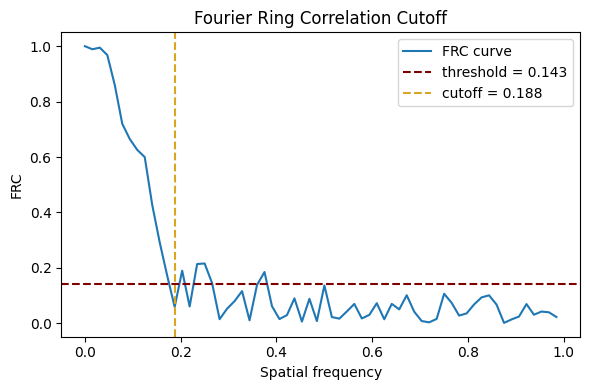

In [ ]:
def test_frc():
    """
    Simple sanity test for FRC + FRCLoss.
    """

    # ---------------------------------
    # 1. Create synthetic images
    # ---------------------------------
    size = 128

    x = torch.linspace(-1, 1, size)
    y = torch.linspace(-1, 1, size)
    xx, yy = torch.meshgrid(x, y, indexing="xy")

    # Base image: smooth Gaussian
    img1 = torch.exp(-(xx**2 + yy**2))

    # Slightly degraded version (blur + noise)
    noise = 0.05 * torch.randn_like(img1)
    img2 = torch.exp(-(xx**2 + yy**2) * 1.2) + noise

    img1 = img1.float()
    img2 = img2.float()

    # ---------------------------------
    # 2. Compute FRC
    # ---------------------------------
    frc, freq = get_fourier_ring_correlations(img1, img2)

    # ---------------------------------
    # 3. Compute loss
    # ---------------------------------
    loss = FRCLoss()(img1, img2)
    print(f"FRC Loss: {loss.item():.4f}")

    test_close(loss, 1.0 - frc.mean())

    # ---------------------------------
    # 4. Plot
    # ---------------------------------
    FCRCutoff(img1, img2, threshold=1/7, plot=True)


# Run test
test_frc()

## Combined Losses

In [ ]:
#| export

class CombinedLoss(_Loss):
    """
    Combined SSIM, MSE, and MAE loss.

    This loss computes a weighted combination of Structural Similarity
    Index Measure (SSIM), Mean Squared Error (MSE), and Mean Absolute
    Error (MAE):

    ``loss = w_ssim * SSIMLoss + w_mse * MSELoss + w_mae * MAELoss``

    where:

    ``w_ssim = 1 - mse_weight - mae_weight``

    The default weights give equal contributions from SSIM, MSE, and
    MAE.

    Parameters
    ----------
    spatial_dims : int, default=2
        Number of spatial dimensions in the input images.

    mse_weight : float, default=0.33
        Weight assigned to the MSE component.

    mae_weight : float, default=0.33
        Weight assigned to the MAE component.

    reduction : str, default="mean"
        Reduction applied to the combined loss. Supported values are
        ``"none"``, ``"mean"``, and ``"sum"``.

    Notes
    -----
    The SSIM component is computed using MONAI's ``SSIMLoss``.
    MSE and MAE are computed using PyTorch's ``MSELoss`` and
    ``L1Loss``.

    ``mse_weight + mae_weight`` must not exceed 1.0.

    References
    ----------
    Shah, Z. H., Müller, M., Hammer, B., Huser, T., & Schenck, W.
    (2022). Impact of different loss functions on denoising of
    microscopic images. *2022 International Joint Conference on
    Neural Networks (IJCNN)*, 1-10.
    """

    def __init__(
        self,
        spatial_dims: int = 2,
        mse_weight: float = 0.33,
        mae_weight: float = 0.33,
        reduction: str = "mean",
    ):
        super().__init__(reduction=reduction)

        if mse_weight < 0 or mae_weight < 0:
            raise ValueError("mse_weight and mae_weight must be non-negative.")

        if mse_weight + mae_weight > 1:
            raise ValueError(
                "mse_weight + mae_weight must not exceed 1.0."
            )

        self.spatial_dims = spatial_dims
        self.mse_weight = mse_weight
        self.mae_weight = mae_weight
        self.ssim_weight = 1.0 - mse_weight - mae_weight

        self.ssim_loss = SSIMLoss(
            spatial_dims=spatial_dims,
            reduction=reduction,
        )
        self.mse_loss = nn.MSELoss(reduction=reduction)
        self.mae_loss = nn.L1Loss(reduction=reduction)

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the combined loss.

        Parameters
        ----------
        input : torch.Tensor
            Predicted images.

        target : torch.Tensor
            Target/reference images.

        Returns
        -------
        torch.Tensor
            Weighted combination of SSIM, MSE, and MAE losses.
        """
        return (
            self.ssim_weight * self.ssim_loss(input, target)
            + self.mse_weight * self.mse_loss(input, target)
            + self.mae_weight * self.mae_loss(input, target)
        )

In [ ]:
#| export

class MSSSIMLoss(_Loss):
    """
    Multi-Scale Structural Similarity (MS-SSIM) loss.

    The loss computes SSIM at multiple spatial scales and combines the
    resulting values using scale-specific weights.

    Parameters
    ----------
    spatial_dims : int, default=2
        Number of spatial dimensions of the input images. Supported
        values are ``2`` and ``3``.

    window_size : int, default=8
        Size of the SSIM Gaussian window.

    sigma : float, default=1.5
        Standard deviation of the Gaussian SSIM kernel.

    reduction : str, default="mean"
        Reduction applied to the output. Supported values are
        ``"none"``, ``"mean"``, and ``"sum"``.

    levels : int, default=3
        Number of spatial scales used to compute MS-SSIM.

    weights : sequence of float, optional
        Weight assigned to each scale. If ``None``, the standard
        five-level MS-SSIM weights are used:

        ``[0.0448, 0.2856, 0.3001, 0.2363, 0.1333]``

        Only the first ``levels`` weights are used.

    Notes
    -----
    Images are downsampled by a factor of two between successive
    scales using average pooling.

    The scale weights are normalized by their sum before combining
    the SSIM values.

    The weights are registered as a buffer, so they automatically
    follow the module when moved between devices.

    References
    ----------
    Wang, Z., Simoncelli, E. P., & Bovik, A. C. (2003).
    Multiscale structural similarity for image quality assessment.
    *The Thirty-Seventh Asilomar Conference on Signals, Systems &
    Computers*, 1398-1402.
    """

    def __init__(
        self,
        spatial_dims: int = 2,
        window_size: int = 8,
        sigma: float = 1.5,
        reduction: str = "mean",
        levels: int = 3,
        weights=None,
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if spatial_dims not in (2, 3):
            raise ValueError(
                f"spatial_dims must be 2 or 3, got {spatial_dims}."
            )

        if levels < 1:
            raise ValueError(
                f"levels must be at least 1, got {levels}."
            )

        default_weights = torch.tensor(
            [0.0448, 0.2856, 0.3001, 0.2363, 0.1333],
            dtype=torch.float32,
        )

        if weights is None:
            weights = default_weights
        else:
            weights = torch.as_tensor(
                weights,
                dtype=torch.float32,
            )

        if len(weights) < levels:
            raise ValueError(
                f"Number of weights ({len(weights)}) must be at least "
                f"the number of levels ({levels})."
            )

        weights = weights[:levels]

        if torch.sum(weights) <= 0:
            raise ValueError("weights must have a positive sum.")

        self.spatial_dims = spatial_dims
        self.window_size = window_size
        self.sigma = sigma
        self.levels = levels

        self.register_buffer("weights", weights)

        self.ssim = SSIMLoss(
            spatial_dims=spatial_dims,
            win_size=window_size,
            kernel_sigma=sigma,
            reduction="none",
        )

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the multi-scale SSIM loss.

        Parameters
        ----------
        input : torch.Tensor
            Predicted images with shape
            ``(B, C, H, W)`` for 2D or
            ``(B, C, D, H, W)`` for 3D.

        target : torch.Tensor
            Target images with the same shape as ``input``.

        Returns
        -------
        torch.Tensor
            MS-SSIM loss, defined as ``1 - MS-SSIM``.
            The output is reduced according to ``reduction``.
        """
        if input.shape != target.shape:
            raise ValueError(
                "Input and target images must have the same dimensions. "
                f"Got {input.shape} and {target.shape}."
            )

        pool = (
            F.avg_pool2d
            if self.spatial_dims == 2
            else F.avg_pool3d
        )

        ssim_values = []
        x, y = input, target

        for i in range(self.levels):
            ssim_value = self.ssim(x, y)

            ssim_values.append(ssim_value)

            if i < self.levels - 1:
                x = pool(x, kernel_size=2, stride=2)
                y = pool(y, kernel_size=2, stride=2)

        weights = self.weights.to(
            device=input.device,
            dtype=input.dtype,
        )

        # Stack along a new scale dimension.
        ssim_values = torch.stack(ssim_values, dim=0)

        # Normalize the scale weights.
        weights = weights / weights.sum()

        # Weighted MS-SSIM.
        view_shape = (self.levels,) + (1,) * (ssim_values.ndim - 1)
        msssim = (
            ssim_values * weights.view(view_shape)
        ).sum(dim=0)

        # Convert similarity to loss.
        loss = 1.0 - msssim

        if self.reduction == LossReduction.MEAN.value:
            loss = torch.mean(loss)
        elif self.reduction == LossReduction.SUM.value:
            loss = torch.sum(loss)

        return loss


In [ ]:
# Test MSSSIMLoss & SSIMLoss
batch_size, channels, height, width = 2, 1, 128, 128
input_tensor = torch.randn(batch_size, channels, height, width)
target_tensor = torch.randn(batch_size, channels, height, width)

msssim_loss = MSSSIMLoss(spatial_dims=2, levels=3)
ssim_loss = SSIMLoss(spatial_dims=2)

loss_msssim = msssim_loss(input_tensor, target_tensor)
loss_ssim = ssim_loss(input_tensor, target_tensor)

# Both should return scalar tensors
test_is(loss_msssim.dim(), 0) # MS-SSIM loss should return a scalar
test_is(loss_ssim.dim(), 0) #SSIM loss should return a scalar


In [ ]:
#| export

class MSSSIML1Loss(_Loss):
    """
    Multi-Scale Structural Similarity (MS-SSIM) combined with Gaussian-weighted
    L1 loss.

    The loss combines MS-SSIM and L1 reconstruction terms as described in:

        Zhao, H., Gallo, O., Frosio, I., & Kautz, J. (2016).
        Loss functions for image restoration with neural networks.
        IEEE Transactions on Computational Imaging, 3(1), 47-57.

    The combined loss is defined as:

        L = alpha * MS-SSIM + (1 - alpha) * L1

    where the L1 term is spatially weighted using a Gaussian centered in the
    image or volume.

    Parameters
    ----------
    spatial_dims : int
        Number of spatial dimensions. Supported values are 2 and 3.
    alpha : float
        Weight assigned to the MS-SSIM loss. The L1 term receives
        ``1 - alpha``.
    window_size : int
        Size of the Gaussian window used by :class:`MSSSIMLoss`.
    sigma : float
        Standard deviation of the Gaussian filter used by MS-SSIM.
    reduction : str
        Reduction applied to the final loss. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.
    levels : int
        Number of scales used by MS-SSIM.
    weights : sequence, optional
        Weights assigned to the different MS-SSIM scales. If ``None``,
        the default MS-SSIM weights are used.

    Notes
    -----
    Inputs are expected to have shape ``(B, C, *spatial_dims)``.
    """

    def __init__(
        self,
        spatial_dims: int = 2,
        alpha: float = 0.025,
        window_size: int = 8,
        sigma: float = 1.5,
        reduction: str = "mean",
        levels: int = 3,
        weights=None,
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if spatial_dims not in (2, 3):
            raise ValueError(
                f"spatial_dims must be 2 or 3, got {spatial_dims}."
            )

        if not 0.0 <= alpha <= 1.0:
            raise ValueError(
                f"alpha must be between 0 and 1, got {alpha}."
            )

        self.spatial_dims = spatial_dims
        self.alpha = alpha
        self.window_size = window_size
        self.sigma = sigma
        self.levels = levels

        self.msssim = MSSSIMLoss(
            spatial_dims=spatial_dims,
            window_size=window_size,
            sigma=sigma,
            reduction="none",
            levels=levels,
            weights=weights,
        )

    def forward(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        Compute the combined MS-SSIM and Gaussian-weighted L1 loss.
        """
        if input.shape != target.shape:
            raise ValueError(
                f"Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        # MS-SSIM loss.
        msssim_loss = self.msssim(input, target)

        # Gaussian-weighted L1 loss.
        gaussian = self.get_gaussian_weight(
            input.shape,
            device=input.device,
            dtype=input.dtype,
        )

        l1_loss = F.l1_loss(input, target, reduction="none") * gaussian

        # Reduce over channels and spatial dimensions while preserving batch.
        reduce_dims = tuple(range(1, input.ndim))

        if self.reduction == LossReduction.MEAN.value:
            l1_loss = l1_loss.sum(dim=reduce_dims)
        elif self.reduction == LossReduction.SUM.value:
            l1_loss = l1_loss.sum(dim=reduce_dims)
        else:
            # For "none", keep the element-wise weighted L1 loss.
            pass

        combined_loss = (
            self.alpha * msssim_loss
            + (1.0 - self.alpha) * l1_loss
        )

        if self.reduction == LossReduction.MEAN.value:
            return combined_loss.mean()

        if self.reduction == LossReduction.SUM.value:
            return combined_loss.sum()

        return combined_loss

    def get_gaussian_weight(
        self,
        size,
        device=None,
        dtype=None,
    ) -> torch.Tensor:
        """
        Generate a normalized Gaussian spatial weighting tensor.

        Parameters
        ----------
        size : tuple
            Input tensor shape ``(B, C, *spatial_dims)``.
        device : torch.device, optional
            Device on which to create the weighting tensor.
        dtype : torch.dtype, optional
            Data type of the weighting tensor.

        Returns
        -------
        torch.Tensor
            Gaussian weights with shape matching ``size``.
        """
        if device is None:
            device = torch.device("cpu")

        if dtype is None:
            dtype = torch.float32

        batch_size, channels, *spatial_shape = size

        if len(spatial_shape) == 2:
            height, width = spatial_shape

            sigma = width / 6.0

            y = torch.arange(
                height,
                device=device,
                dtype=dtype,
            )
            x = torch.arange(
                width,
                device=device,
                dtype=dtype,
            )

            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0

            y_grid, x_grid = torch.meshgrid(
                y,
                x,
                indexing="ij",
            )

            gaussian = torch.exp(
                -(
                    (y_grid - center_y) ** 2
                    + (x_grid - center_x) ** 2
                )
                / (2.0 * sigma**2)
            )

            gaussian = gaussian / gaussian.sum()

            return gaussian.view(
                1, 1, height, width
            ).expand(
                batch_size, channels, height, width
            )

        if len(spatial_shape) == 3:
            depth, height, width = spatial_shape

            sigma = width / 6.0

            z = torch.arange(
                depth,
                device=device,
                dtype=dtype,
            )
            y = torch.arange(
                height,
                device=device,
                dtype=dtype,
            )
            x = torch.arange(
                width,
                device=device,
                dtype=dtype,
            )

            center_z = (depth - 1) / 2.0
            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0

            z_grid, y_grid, x_grid = torch.meshgrid(
                z,
                y,
                x,
                indexing="ij",
            )

            gaussian = torch.exp(
                -(
                    (z_grid - center_z) ** 2
                    + (y_grid - center_y) ** 2
                    + (x_grid - center_x) ** 2
                )
                / (2.0 * sigma**2)
            )

            gaussian = gaussian / gaussian.sum()

            return gaussian.view(
                1, 1, depth, height, width
            ).expand(
                batch_size,
                channels,
                depth,
                height,
                width,
            )

        raise ValueError(
            f"Expected 2D or 3D spatial input, got "
            f"{len(spatial_shape)} spatial dimensions."
        )

In [ ]:
msssiml1_loss = MSSSIML1Loss(alpha=0.025, window_size=11, sigma=1.5, levels=3)
input_image = torch.randn(4, 1, 128, 128)  # Batch of 4 grayscale images (1 channel)
target_image = torch.randn(4, 1, 128, 128)

# Compute MSSSIM + Gaussian-weighted L1 loss
loss = msssiml1_loss(input_image, target_image)
loss2 = ssim_loss(input_image, target_image)
print("ms-ssim l1: ", loss, '\nssim: ', loss2)

test_is(loss.dim(), 0)
test_is(loss2.dim(), 0)

ms-ssim l1:  tensor(1.0985) 
ssim:  tensor(0.9956)


In [ ]:
#| export

class MSSSIML2Loss(_Loss):
    """
    Multi-Scale Structural Similarity (MS-SSIM) combined with
    Gaussian-weighted L2 loss.

    The loss combines MS-SSIM and L2 reconstruction terms as described in:

        Zhao, H., Gallo, O., Frosio, I., & Kautz, J. (2016).
        Loss functions for image restoration with neural networks.
        IEEE Transactions on Computational Imaging, 3(1), 47-57.

    The combined loss is defined as:

        L = alpha * MS-SSIM + (1 - alpha) * L2

    where the L2 term is spatially weighted using a Gaussian centered
    in the image or volume.

    Parameters
    ----------
    spatial_dims : int
        Number of spatial dimensions. Supported values are 2 and 3.
    alpha : float
        Weight assigned to the MS-SSIM loss. The L2 term receives
        ``1 - alpha``.
    window_size : int
        Size of the Gaussian window used by :class:`MSSSIMLoss`.
    sigma : float
        Standard deviation of the Gaussian filter used by MS-SSIM.
    reduction : str
        Reduction applied to the final loss. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.
    levels : int
        Number of scales used by MS-SSIM.
    weights : sequence, optional
        Weights assigned to the different MS-SSIM scales. If ``None``,
        the default MS-SSIM weights are used.

    Notes
    -----
    Inputs are expected to have shape ``(B, C, *spatial_dims)``.
    """

    def __init__(
        self,
        spatial_dims: int = 2,
        alpha: float = 0.1,
        window_size: int = 11,
        sigma: float = 1.5,
        reduction: str = "mean",
        levels: int = 3,
        weights=None,
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if spatial_dims not in (2, 3):
            raise ValueError(
                f"spatial_dims must be 2 or 3, got {spatial_dims}."
            )

        if not 0.0 <= alpha <= 1.0:
            raise ValueError(
                f"alpha must be between 0 and 1, got {alpha}."
            )

        self.spatial_dims = spatial_dims
        self.alpha = alpha
        self.window_size = window_size
        self.sigma = sigma
        self.levels = levels

        self.msssim = MSSSIMLoss(
            spatial_dims=spatial_dims,
            window_size=window_size,
            sigma=sigma,
            reduction="none",
            levels=levels,
            weights=weights,
        )

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the combined MS-SSIM and Gaussian-weighted L2 loss.
        """
        if input.shape != target.shape:
            raise ValueError(
                f"Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        # MS-SSIM loss.
        msssim_loss = self.msssim(input, target)

        # Gaussian-weighted L2 loss.
        gaussian = self.get_gaussian_weight(
            input.shape,
            device=input.device,
            dtype=input.dtype,
        )

        l2_loss = F.mse_loss(
            input,
            target,
            reduction="none",
        ) * gaussian

        # Reduce channel and spatial dimensions while preserving batch.
        reduce_dims = tuple(range(1, input.ndim))

        if self.reduction == LossReduction.MEAN.value:
            # Gaussian is normalized, so sum gives the weighted mean.
            l2_loss = l2_loss.sum(dim=reduce_dims)

        elif self.reduction == LossReduction.SUM.value:
            l2_loss = l2_loss.sum(dim=reduce_dims)

        # For "none", retain the element-wise weighted L2 loss.

        combined_loss = (
            self.alpha * msssim_loss
            + (1.0 - self.alpha) * l2_loss
        )

        if self.reduction == LossReduction.MEAN.value:
            return combined_loss.mean()

        if self.reduction == LossReduction.SUM.value:
            return combined_loss.sum()

        return combined_loss

    def get_gaussian_weight(
        self,
        size,
        device=None,
        dtype=None,
    ) -> torch.Tensor:
        """
        Generate a normalized Gaussian spatial weighting tensor.

        Parameters
        ----------
        size : tuple
            Input tensor shape ``(B, C, *spatial_dims)``.
        device : torch.device, optional
            Device on which to create the weighting tensor.
        dtype : torch.dtype, optional
            Data type of the weighting tensor.

        Returns
        -------
        torch.Tensor
            Gaussian weights with the same shape as the input.
        """
        if device is None:
            device = torch.device("cpu")

        if dtype is None:
            dtype = torch.float32

        batch_size, channels, *spatial_shape = size

        if len(spatial_shape) == 2:
            height, width = spatial_shape

            sigma = width / 6.0

            y = torch.arange(
                height,
                device=device,
                dtype=dtype,
            )
            x = torch.arange(
                width,
                device=device,
                dtype=dtype,
            )

            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0

            y_grid, x_grid = torch.meshgrid(
                y,
                x,
                indexing="ij",
            )

            gaussian = torch.exp(
                -(
                    (y_grid - center_y) ** 2
                    + (x_grid - center_x) ** 2
                )
                / (2.0 * sigma**2)
            )

            gaussian = gaussian / gaussian.sum()

            return gaussian.view(
                1, 1, height, width
            ).expand(
                batch_size,
                channels,
                height,
                width,
            )

        if len(spatial_shape) == 3:
            depth, height, width = spatial_shape

            sigma = width / 6.0

            z = torch.arange(
                depth,
                device=device,
                dtype=dtype,
            )
            y = torch.arange(
                height,
                device=device,
                dtype=dtype,
            )
            x = torch.arange(
                width,
                device=device,
                dtype=dtype,
            )

            center_z = (depth - 1) / 2.0
            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0

            z_grid, y_grid, x_grid = torch.meshgrid(
                z,
                y,
                x,
                indexing="ij",
            )

            gaussian = torch.exp(
                -(
                    (z_grid - center_z) ** 2
                    + (y_grid - center_y) ** 2
                    + (x_grid - center_x) ** 2
                )
                / (2.0 * sigma**2)
            )

            gaussian = gaussian / gaussian.sum()

            return gaussian.view(
                1, 1, depth, height, width
            ).expand(
                batch_size,
                channels,
                depth,
                height,
                width,
            )

        raise ValueError(
            f"Expected 2D or 3D spatial input, got "
            f"{len(spatial_shape)} spatial dimensions."
        )

In [ ]:
msssim_l2_loss = MSSSIML2Loss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
output = torch.rand(10, 3, 64, 64).to(device)  # Example output with even dimensions
target = torch.rand(10, 3, 64, 64).to(device)  # Example target with even dimensions
loss = msssim_l2_loss(output, target)
print("ms-ssim l2:", loss)

test_is(loss.dim(), 0)


ms-ssim l2: tensor(0.4557, device='cuda:0')


In [ ]:
#| export

class CellLoss(_Loss):
    """
    Combined classification and regression loss for cell prediction tasks.

    The first column of ``input`` is treated as a binary classification
    logit indicating cell presence. The remaining columns are treated as
    continuous regression targets.

    The loss is defined as:

        L = 0.5 * MSE(input[:, 1:], 5 * target[:, 1:])
            + BCEWithLogits(input[:, 0], target[:, 0])

    This formulation is based on the cell prediction loss described in:

        Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021).
        Cellpose: a generalist algorithm for cellular segmentation.
        Nature Methods, 18(1), 100-106.

    Parameters
    ----------
    reduction : str
        Reduction applied to the final loss. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.

    Notes
    -----
    The input tensors are expected to have shape ``(B, N)`` with at least
    two columns:

    - ``input[:, 0]``: cell-presence logit
    - ``input[:, 1:]``: regression predictions

    The corresponding target tensor must have the same shape.
    """

    def __init__(
        self,
        reduction: str = "mean",
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        self.mse_loss = nn.MSELoss(reduction="none")
        self.bce_loss = nn.BCEWithLogitsLoss(reduction="none")

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the combined classification and regression loss.
        """
        if input.shape != target.shape:
            raise ValueError(
                f"Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        if input.ndim < 2 or input.shape[1] < 2:
            raise ValueError(
                "CellLoss expects tensors with shape (B, N), "
                "where N >= 2."
            )

        # Regression loss.
        regression_loss = self.mse_loss(
            input[:, 1:],
            5.0 * target[:, 1:],
        )

        # Classification loss.
        classification_loss = self.bce_loss(
            input[:, 0],
            target[:, 0],
        )

        # Reduce the regression dimensions first so that both terms
        # contribute one value per sample.
        regression_loss = regression_loss.mean(dim=1)

        combined_loss = (
            0.5 * regression_loss
            + classification_loss
        )

        if self.reduction == LossReduction.MEAN.value:
            return combined_loss.mean()

        if self.reduction == LossReduction.SUM.value:
            return combined_loss.sum()

        return combined_loss

In [ ]:
#| export

class InstanceSegLoss(_Loss):
    """
    Combined BCE, MSE, and SSIM loss for instance segmentation.

    All channels of ``input`` and ``target`` are treated as independent
    instance masks. Each channel represents one object instance.

    The loss is defined as:

        L = BCE + mse_weight * MSE + ssim_weight * SSIM

    where the BCE term uses logits when ``logits=True``.

    This loss is a variation of the CellLoss formulation described in:

        Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021).
        Cellpose: a generalist algorithm for cellular segmentation.
        Nature Methods, 18(1), 100-106.

    Parameters
    ----------
    mse_weight : float
        Weight applied to the MSE component.
    ssim_weight : float
        Weight applied to the SSIM component.
    spatial_dims : int
        Number of spatial dimensions. Supported values are 2 and 3.
    logits : bool
        If ``True``, ``input`` contains logits and
        :class:`torch.nn.BCEWithLogitsLoss` is used. If ``False``,
        ``input`` is expected to contain probabilities in ``[0, 1]``
        and :class:`torch.nn.BCELoss` is used.
    reduction : str
        Reduction applied to the final loss. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.

    Notes
    -----
    Inputs are expected to have shape ``(B, C, *spatial_dims)``.
    """

    def __init__(
        self,
        mse_weight: float = 0.5,
        ssim_weight: float = 1.0,
        spatial_dims: int = 2,
        logits: bool = True,
        reduction: str = "mean",
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if spatial_dims not in (2, 3):
            raise ValueError(
                f"spatial_dims must be 2 or 3, got {spatial_dims}."
            )

        if mse_weight < 0:
            raise ValueError(
                f"mse_weight must be non-negative, got {mse_weight}."
            )

        if ssim_weight < 0:
            raise ValueError(
                f"ssim_weight must be non-negative, got {ssim_weight}."
            )

        self.mse_weight = mse_weight
        self.ssim_weight = ssim_weight
        self.spatial_dims = spatial_dims
        self.logits = logits

        self.bce_loss = (
            nn.BCEWithLogitsLoss(reduction=reduction)
            if logits
            else nn.BCELoss(reduction=reduction)
        )

        self.mse_loss = nn.MSELoss(reduction=reduction)

        self.ssim_loss = SSIMLoss(
            spatial_dims=spatial_dims,
            reduction=reduction,
        )

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the combined BCE, MSE, and SSIM loss.
        """
        if input.shape != target.shape:
            raise ValueError(
                f"Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        if input.ndim != self.spatial_dims + 2:
            raise ValueError(
                f"Expected input with {self.spatial_dims + 2} dimensions "
                f"(B, C, *spatial_dims), got {input.ndim}."
            )

        # Binary cross-entropy.
        if self.logits:
            bce = self.bce_loss(input, target)
        else:
            if torch.any(input < 0) or torch.any(input > 1):
                raise ValueError(
                    "When logits=False, input must contain probabilities "
                    "in the range [0, 1]."
                )
            bce = self.bce_loss(input, target)

        # Mean squared error.
        mse = self.mse_loss(input, target)

        # Structural similarity.
        ssim = self.ssim_loss(input, target)

        return (
            bce
            + self.mse_weight * mse
            + self.ssim_weight * ssim
        )

In [ ]:
#| export

class DiceBCELoss(_Loss):
    """
    Hybrid Binary Cross-Entropy and Dice loss for multi-channel
    instance segmentation.

    All channels of ``input`` and ``target`` are treated as independent
    binary instance masks. Each channel represents one object instance.

    The loss is defined as:

        L = BCEWithLogits(input, target) + dice_weight * DiceLoss

    where the Dice term is computed from sigmoid probabilities:

        DiceLoss = 1 - (2 * intersection + smooth)
                     / (union + smooth)

    The Dice score is computed independently for each instance channel
    across the batch and spatial dimensions, and then averaged over
    channels.

    Parameters
    ----------
    dice_weight : float
        Weight applied to the Dice loss component.
    smooth : float
        Smoothing constant used to improve numerical stability and avoid
        division by zero.
    reduction : str
        Reduction applied to the BCE term. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.

    Notes
    -----
    Inputs are expected to have shape ``(B, C, *spatial_dims)``.
    The Dice calculation always preserves the channel dimension until
    the final channel-wise average.
    """

    def __init__(
        self,
        dice_weight: float = 1.0,
        smooth: float = 1e-6,
        reduction: str = "mean",
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if dice_weight < 0:
            raise ValueError(
                f"dice_weight must be non-negative, got {dice_weight}."
            )

        if smooth < 0:
            raise ValueError(
                f"smooth must be non-negative, got {smooth}."
            )

        self.dice_weight = dice_weight
        self.smooth = smooth

        self.bce_loss = nn.BCEWithLogitsLoss(
            reduction=reduction,
        )

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the hybrid BCE + Dice segmentation loss.
        """
        if input.shape != target.shape:
            raise ValueError(
                f"Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        if input.ndim < 3:
            raise ValueError(
                "DiceBCELoss expects tensors with shape "
                "(B, C, *spatial_dims)."
            )

        # BCE component operates directly on logits.
        bce = self.bce_loss(input, target)

        # Dice component operates on probabilities.
        prob = torch.sigmoid(input)

        # Sum over batch and all spatial dimensions while keeping
        # instance channels independent.
        dims = (0,) + tuple(range(2, input.ndim))

        intersection = (prob * target).sum(dim=dims)
        union = prob.sum(dim=dims) + target.sum(dim=dims)

        dice = 1.0 - (
            2.0 * intersection + self.smooth
        ) / (
            union + self.smooth
        )

        # Average the Dice loss over instance channels.
        dice = dice.mean()

        return bce + self.dice_weight * dice

## Segmentation losses

In [ ]:
#| export

class DiceLoss(ml.DiceLoss):
    """
    Dice loss for measuring overlap between predicted and target regions.

    The Dice coefficient is

        Dice = (2 * intersection + smooth)
               / (prediction_sum + target_sum + smooth)

    and the corresponding loss is

        L_Dice = 1 - Dice.

    Dice loss is particularly useful for segmentation tasks, especially
    when foreground and background classes are highly imbalanced.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.DiceLoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.DiceLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The complete constructor API and behavior are inherited unchanged.

    Examples
    --------
    >>> loss = DiceLoss(sigmoid=True)
    >>> value = loss(prediction, target)
    """
    pass


In [ ]:
#| export

class MaskedDiceLoss(ml.MaskedDiceLoss):
    """
    Dice loss computed using a spatial mask.

    This loss extends the Dice loss by restricting the computation to
    locations selected by a mask. This is useful when only specific
    regions of an image should contribute to the segmentation loss.

    Conceptually,

        L = 1 - Dice(input * mask, target * mask)

    where ``mask`` determines which spatial locations participate in
    the loss calculation.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.MaskedDiceLoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.MaskedDiceLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The complete constructor and masking behavior are inherited unchanged.

    Examples
    --------
    >>> loss = MaskedDiceLoss(sigmoid=True)
    >>> value = loss(prediction, target, mask)
    """
    pass

In [ ]:
#| export

class GeneralizedDiceLoss(ml.GeneralizedDiceLoss):
    """
    Generalized Dice loss for multi-class segmentation.

    Generalized Dice loss extends the standard Dice formulation by
    weighting classes according to their target volume. This reduces
    the influence of large classes and makes the loss more robust to
    severe class imbalance.

    A common formulation is

        GDL = 1 - 2 * Σ_c w_c Σ_i p_ic y_ic
                  / (Σ_c w_c Σ_i p_ic + Σ_c w_c Σ_i y_ic)

    where:

    - ``p_ic`` is the prediction for class ``c`` at location ``i``,
    - ``y_ic`` is the corresponding target,
    - ``w_c`` is a class-dependent weight, commonly related to the
      inverse squared target volume.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.GeneralizedDiceLoss`.
    **kwargs
        Keyword arguments passed to
        :class:`monai.losses.GeneralizedDiceLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The exact weighting, activation, smoothing, and reduction behavior
    are inherited from MONAI.

    Examples
    --------
    >>> loss = GeneralizedDiceLoss(softmax=True)
    >>> value = loss(prediction, target)
    """
    pass

In [ ]:
#| export

class GeneralizedWassersteinDiceLoss(ml.GeneralizedWassersteinDiceLoss):
    """
    Generalized Wasserstein Dice loss for multi-class segmentation.

    This loss combines the generalized Dice formulation with a
    Wasserstein distance between classes. A class-distance matrix can
    therefore encode the semantic or anatomical similarity between
    classes.

    Conceptually, the loss combines overlap information with a
    Wasserstein-based distance:

        L = Dice-based term + Wasserstein-based term.

    Unlike ordinary Dice loss, which treats all incorrect class
    predictions equally, the Wasserstein formulation can assign
    different penalties to different types of class confusion.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.GeneralizedWassersteinDiceLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The class-distance matrix and all weighting parameters are handled
    by MONAI.

    Examples
    --------
    >>> loss = GeneralizedWassersteinDiceLoss(dist_matrix=dist_matrix)
    >>> value = loss(prediction, target)
    """
    pass

In [ ]:
#| export

class DiceCELoss(ml.DiceCELoss):
    """
    Combined Dice and Cross-Entropy loss.

    This loss combines the region-overlap properties of Dice loss with
    the probabilistic classification properties of Cross-Entropy loss.

    Conceptually,

        L = λ_Dice L_Dice + λ_CE L_CE

    where ``λ_Dice`` and ``λ_CE`` control the contribution of each term.

    Dice loss encourages agreement between predicted and target regions,
    while Cross-Entropy provides voxel-wise supervision and generally
    improves class discrimination.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.DiceCELoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.DiceCELoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    Activation handling, weighting, smoothing, and reduction are
    inherited from MONAI.

    Examples
    --------
    >>> loss = DiceCELoss(to_onehot_y=True, softmax=True)
    >>> value = loss(prediction, target)
    """
    pass

In [ ]:
#| export

class DiceFocalLoss(ml.DiceFocalLoss):
    """
    Combined Dice and Focal loss for segmentation.

    This loss combines region-level Dice overlap with Focal loss,
    providing both spatial overlap supervision and increased emphasis
    on difficult or misclassified examples.

    Conceptually,

        L = λ_Dice L_Dice + λ_Focal L_Focal.

    Focal loss modifies the standard classification loss so that
    well-classified examples contribute less:

        L_Focal ∝ -(1 - p_t)^γ log(p_t)

    where ``p_t`` is the predicted probability of the target class and
    ``γ`` controls the focusing strength.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.DiceFocalLoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.DiceFocalLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The Dice/Focal weighting, activation handling, and reduction are
    inherited unchanged.

    Examples
    --------
    >>> loss = DiceFocalLoss(to_onehot_y=True, softmax=True)
    >>> value = loss(prediction, target)
    """
    pass

In [ ]:
#| export

class GeneralizedDiceFocalLoss(ml.GeneralizedDiceFocalLoss):
    """
    Combined Generalized Dice and Focal loss.

    This loss combines Generalized Dice loss, which compensates for
    class imbalance using class-dependent weights, with Focal loss,
    which emphasizes difficult examples.

    Conceptually,

        L = λ_GDice L_GDice + λ_Focal L_Focal.

    Generalized Dice provides global region-level supervision, while
    Focal loss focuses optimization on voxels that remain difficult to
    classify.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.GeneralizedDiceFocalLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    Class weighting, focal parameters, activation handling, and
    reduction are inherited from MONAI.

    Examples
    --------
    >>> loss = GeneralizedDiceFocalLoss(to_onehot_y=True, softmax=True)
    >>> value = loss(prediction, target)
    """
    pass

In [ ]:
#| export

class FocalLoss(ml.FocalLoss):
    """
    Focal loss for classification and segmentation.

    Focal loss modifies Cross-Entropy to reduce the contribution of
    well-classified examples and focus optimization on difficult
    examples.

    For a target class with predicted probability ``p_t``,

        L_Focal = -α_t (1 - p_t)^γ log(p_t)

    where:

    - ``p_t`` is the predicted probability of the target class,
    - ``α_t`` optionally balances classes,
    - ``γ`` is the focusing parameter.

    When ``γ = 0``, the focal modulation disappears and the loss
    reduces to a class-weighted Cross-Entropy formulation.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.FocalLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.

    Examples
    --------
    >>> loss = FocalLoss()
    >>> value = loss(prediction, target)
    """
    pass

In [ ]:
#| export

class TverskyLoss(ml.TverskyLoss):
    """
    Tversky loss for imbalanced image segmentation.

    The Tversky index generalizes the Dice coefficient by allowing
    false positives and false negatives to receive different weights.

    The Tversky index is

        T = TP / (TP + α FP + β FN)

    and the corresponding loss is

        L_Tversky = 1 - T.

    Here:

    - ``TP`` denotes true positives,
    - ``FP`` denotes false positives,
    - ``FN`` denotes false negatives,
    - ``α`` controls the penalty for false positives,
    - ``β`` controls the penalty for false negatives.

    Choosing different values of ``α`` and ``β`` allows the loss to
    emphasize precision or recall.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.TverskyLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The exact parameterization and reduction behavior are inherited
    unchanged.

    Examples
    --------
    >>> loss = TverskyLoss(sigmoid=True, alpha=0.3, beta=0.7)
    >>> value = loss(prediction, target)
    """
    pass

In [ ]:
#| export

class ContrastiveLoss(ml.ContrastiveLoss):
    """
    Contrastive loss for learning meaningful embedding representations.

    Contrastive loss encourages samples from the same class or
    identity to have similar representations, while pushing samples
    from different classes apart.

    A common pair-based formulation is

        L = (1 - y) * D²
            + y * max(margin - D, 0)²,

    where:

    - ``D`` is the distance between the two representations,
    - ``y`` identifies the pair relationship,
    - ``margin`` specifies the minimum desired separation.

    The exact target convention and formulation are determined by the
    underlying MONAI implementation.

    Contrastive loss is commonly used for metric learning, embedding
    learning, and representation learning.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.ContrastiveLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The complete constructor and forward behavior are inherited unchanged.

    Examples
    --------
    >>> loss = ContrastiveLoss()
    >>> value = loss(embedding1, embedding2, target)
    """
    pass

In [ ]:
#| export
@add_method(CrossEntropyLoss)
def activation(self, x):
    return F.softmax(x, dim=1)

In [ ]:
#| export

class CrossEntropyLossFlat3D(CrossEntropyLossFlat):
    """
    Cross-Entropy loss for 3D inputs with flattened spatial dimensions.

    This loss is equivalent to :class:`CrossEntropyLossFlat`, but is
    specialized for 3D classification or segmentation inputs using the
    conventional channel-first layout:

        input:  (N, C, D, H, W)
        target: (N, D, H, W)

    The class dimension is moved to the last position before flattening:

        (N, C, D, H, W) -> (N, D, H, W, C)

    and, when ``flatten=True``, the tensors are reshaped to:

        input:  (N*D*H*W, C)
        target: (N*D*H*W,)

    The underlying loss is therefore applied independently to every
    voxel while treating the ``C`` dimension as the class dimension.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`CrossEntropyLossFlat`.
    **kwargs
        Keyword arguments passed to :class:`CrossEntropyLossFlat`.

    Notes
    -----
    This implementation assumes a channel-first 3D input with shape
    ``(N, C, D, H, W)``.

    When ``flatten=False``, the class dimension is still moved to the
    last position, but no additional flattening is performed.

    Examples
    --------
    >>> loss = CrossEntropyLossFlat3D()
    >>> inp = torch.randn(2, 4, 16, 32, 32)
    >>> targ = torch.randint(0, 4, (2, 16, 32, 32))
    >>> value = loss(inp, targ)

    See Also
    --------
    CrossEntropyLossFlat
        General flattened Cross-Entropy loss.
    torch.nn.CrossEntropyLoss
        PyTorch implementation of Cross-Entropy loss.
    """

    def __call__(
        self,
        inp: torchTensor,
        targ: torchTensor,
        **kwargs,
    ) -> torchTensor:
        """Move the class axis to the end, flatten spatial dimensions, and compute the loss."""
        if inp.ndim != 5:
            raise ValueError(
                f"CrossEntropyLossFlat3D expects input with shape "
                f"(N, C, D, H, W), got {tuple(inp.shape)}."
            )

        inp = inp.permute(0, 2, 3, 4, 1).contiguous()
        targ = targ.contiguous()

        if self.flatten:
            inp = inp.view(-1, inp.shape[-1])
            targ = targ.view(-1)

        return self.func(inp, targ, **kwargs)

In [ ]:
#| export

class BCELoss(nn.BCEWithLogitsLoss):
    """
    Binary Cross-Entropy loss with logits for multi-channel segmentation.

    Each channel is treated as an independent binary prediction. This is
    appropriate for multi-label or instance segmentation, where each
    channel represents an object instance and different instances may
    overlap.

    For each element, the binary cross-entropy with logits is

        L(x, y) = -[y log(σ(x)) + (1-y) log(1-σ(x))]

    where:

    - ``x`` is the raw model logit,
    - ``y`` is the binary target,
    - ``σ(x)`` is the sigmoid probability.

    The sigmoid operation is incorporated directly into the loss for
    numerical stability.

    For an input with shape ``(N, K, ...)``, where ``K`` is the number
    of instance channels, the loss is applied independently to every
    channel and spatial location before the selected reduction.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`torch.nn.BCEWithLogitsLoss`.
    **kwargs
        Keyword arguments passed to :class:`torch.nn.BCEWithLogitsLoss`,
        including ``weight``, ``reduction``, and ``pos_weight``.

    Notes
    -----
    Despite the ``BCELoss`` name, this class operates on **logits**, not
    probabilities. Do not apply ``sigmoid`` to the model output before
    passing it to this loss.

    This is a thin bioMONAI wrapper around
    :class:`torch.nn.BCEWithLogitsLoss`, preserving its standard API.

    Examples
    --------
    >>> loss = BCELoss()
    >>> pred = torch.randn(2, 3, 64, 64)
    >>> targ = torch.randint(0, 2, (2, 3, 64, 64)).float()
    >>> value = loss(pred, targ)

    For imbalanced instance masks, positive examples can be weighted:

    >>> loss = BCELoss(pos_weight=torch.tensor([2.0, 2.0, 3.0]))
    """
    pass

In [ ]:

inputs = randn((1, 1, 256, 256))  # Input
targets = randint(0, 2, (1, 1, 256, 256)).float()  # Ground Truth

# Initialize
dice_loss = DiceLoss()

# Compute loss
loss = dice_loss(inputs, targets)
print('Dice Loss:', loss.item())

test_is(loss.dim(), 0)

Dice Loss: 0.9951493740081787


## Registration losses


In [ ]:
#| export

class BendingEnergyLoss(ml.BendingEnergyLoss):
    """
    Bending energy loss for smooth deformation fields.

    Bending energy penalizes spatial variations in the deformation field's
    local displacement gradients. It is commonly used in deformable image
    registration to encourage smooth, physically plausible transformations
    while avoiding unnecessary local distortions.

    For a displacement field ``u``, the bending energy is based on its
    second-order spatial derivatives. In a simplified 2D formulation,

        E(u) = ∫ [
            (∂²u_x/∂x²)²
            + (∂²u_x/∂y²)²
            + 2(∂²u_x/∂x∂y)²
            + (∂²u_y/∂x²)²
            + (∂²u_y/∂y²)²
            + 2(∂²u_y/∂x∂y)²
        ] dx dy.

    The 3D formulation similarly includes the second-order derivatives
    with respect to all spatial dimensions.

    Minimizing this energy encourages the deformation field to vary
    smoothly and reduces high-frequency bending and local deformation.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.BendingEnergyLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.BendingEnergyLoss`. The exact input handling,
    spatial dimensionality, and reduction behavior are inherited from
    MONAI.

    The loss is primarily intended for dense displacement fields used
    in deformable image registration rather than for image intensity
    reconstruction.

    Examples
    --------
    >>> loss = BendingEnergyLoss()
    >>> displacement = torch.randn(2, 3, 32, 64, 64)
    >>> value = loss(displacement)

    References
    ----------
    Rueckert, D., et al. (1999).
    Nonrigid registration using free-form deformations:
    application to breast MR images.
    IEEE Transactions on Medical Imaging, 18(8), 712-721.
    """
    pass

In [ ]:
#| export

class DiffusionLoss(ml.DiffusionLoss):
    """
    Diffusion regularization loss for deformation fields.

    This loss penalizes spatial variations in a deformation or displacement
    field using a diffusion-like regularization term. It encourages smooth
    transformations by penalizing first-order spatial derivatives of the
    predicted field.

    For a displacement field ``u``, a common formulation is

        L_diff = ∫ ||∇u(x)||² dx

    or, equivalently, the sum of squared first-order spatial derivatives:

        L_diff = Σ_d Σ_i (∂u_i / ∂x_d)²

    where ``u_i`` denotes a displacement component and ``x_d`` denotes a
    spatial dimension.

    Unlike bending-energy regularization, which penalizes second-order
    derivatives, diffusion regularization penalizes first-order gradients.
    It therefore encourages locally smooth deformation fields.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.DiffusionLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.DiffusionLoss`. The exact derivative computation,
    spatial-dimensionality handling, and reduction behavior are inherited
    from MONAI.

    Examples
    --------
    >>> loss = DiffusionLoss()
    >>> displacement = torch.randn(2, 3, 32, 64, 64)
    >>> value = loss(displacement)
    """
    pass

In [ ]:
#| export

class LocalNormalizedCrossCorrelationLoss(ml.LocalNormalizedCrossCorrelationLoss):
    """
    Local normalized cross-correlation loss for image similarity.

    Local normalized cross-correlation (LNCC) measures the similarity
    between two images by comparing their intensity patterns within
    local neighborhoods.

    For a local window ``W``, normalized cross-correlation can be written
    conceptually as

        NCC(x, y) =
            [Σ_{i∈W} (x_i - μ_x)(y_i - μ_y)]
            /
            sqrt[
                Σ_{i∈W}(x_i - μ_x)²
                Σ_{i∈W}(y_i - μ_y)²
            ]

    where ``μ_x`` and ``μ_y`` are the local means.

    The corresponding loss is typically formulated as

        L_LNCC = -NCC

    or an equivalent monotonic transformation.

    Because the comparison is local and normalized by local intensity
    statistics, LNCC is useful for image registration and is relatively
    insensitive to local differences in intensity scale and offset.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.LocalNormalizedCrossCorrelationLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.LocalNormalizedCrossCorrelationLoss`.

    The neighborhood/window configuration, spatial dimensionality,
    weighting, and reduction behavior are inherited from MONAI.

    Examples
    --------
    >>> loss = LocalNormalizedCrossCorrelationLoss()
    >>> fixed = torch.randn(2, 1, 64, 64)
    >>> moving = torch.randn(2, 1, 64, 64)
    >>> value = loss(fixed, moving)

    References
    ----------
    Avants, B. B., et al. (2008).
    Symmetric diffeomorphic image registration with cross-correlation:
    evaluating automated labeling of elderly and neurodegenerative brain.
    Medical Image Analysis, 12(1), 26-41.
    """
    pass

In [ ]:
#| export

class GlobalMutualInformationLoss(ml.GlobalMutualInformationLoss):
    """
    Global mutual information loss for image similarity.

    Mutual information measures the statistical dependence between the
    intensity distributions of two images. It is particularly useful for
    image registration because it can compare images with different
    intensity relationships or modalities.

    Mutual information is defined as

        MI(X, Y) = Σ_{x,y} p(x,y)
                   log [ p(x,y) / (p(x)p(y)) ]

    where:

    - ``p(x,y)`` is the joint intensity distribution,
    - ``p(x)`` and ``p(y)`` are the corresponding marginal distributions.

    A loss formulation generally minimizes the negative mutual information:

        L_MI = -MI(X, Y)

    The global formulation estimates the intensity relationship over the
    complete image rather than independently within local neighborhoods.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.GlobalMutualInformationLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.GlobalMutualInformationLoss`.

    Histogram estimation, kernel configuration, normalization, spatial
    dimensionality, and reduction behavior are inherited from MONAI.

    Examples
    --------
    >>> loss = GlobalMutualInformationLoss()
    >>> fixed = torch.randn(2, 1, 64, 64)
    >>> moving = torch.randn(2, 1, 64, 64)
    >>> value = loss(fixed, moving)

    References
    ----------
    Viola, P. and Wells, W. M. (1997).
    Alignment by maximization of mutual information.
    International Journal of Computer Vision, 24, 137-154.
    """
    pass

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()